In [ ]:
# STEP 1 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 1.1 — Import library
import os

# STEP 1.2 — Dataset path
BASE_DIR = "/content/drive/MyDrive/SignNumberModel"
RAW_BASE = os.path.join(BASE_DIR, "raw_videos")

VIDEO_EXTS = (".mp4", ".avi", ".mov", ".mkv")

# STEP 1.3 — Check folder exists
if not os.path.exists(RAW_BASE):
    raise FileNotFoundError(f"Folder not found: {RAW_BASE}")

# STEP 1.4 — Get class folders (IMPORTANT: numeric sorting)
class_folders = sorted(
    [d for d in os.listdir(RAW_BASE) if os.path.isdir(os.path.join(RAW_BASE, d))],
    key=lambda x: int(x)
)

print("Detected classes:")
print(class_folders)
print("\nTotal classes:", len(class_folders))


# STEP 1.5 — Rename videos inside each class folder
print("\nRenaming videos...")

for class_folder in class_folders:

    class_path = os.path.join(RAW_BASE, class_folder)

    videos = sorted([
        f for f in os.listdir(class_path)
        if f.lower().endswith(VIDEO_EXTS)
    ])

    for i, video in enumerate(videos, start=1):

        old_path = os.path.join(class_path, video)

        ext = os.path.splitext(video)[1]

        # new name format
        new_name = f"{class_folder}_video{i:02d}{ext}"

        new_path = os.path.join(class_path, new_name)

        # rename only if different
        if old_path != new_path:
            os.rename(old_path, new_path)

    print(f"{class_folder} → {len(videos)} videos renamed")


# STEP 1.6 — Count videos per class
print("\nVideo count per class:")

total = 0

for c in class_folders:

    c_path = os.path.join(RAW_BASE, c)

    vids = [
        f for f in os.listdir(c_path)
        if f.lower().endswith(VIDEO_EXTS)
    ]

    print(f"{c} → {len(vids)} videos")

    total += len(vids)

print("\nTotal videos:", total)

print("\n✅ Dataset check and renaming completed successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detected classes:
['72', '74', '75', '76', '78', '80', '84', '85', '88', '90', '92', '94', '95', '96', '97', '98', '99', '100']

Total classes: 18

Renaming videos...
72 → 17 videos renamed
74 → 17 videos renamed
75 → 17 videos renamed
76 → 17 videos renamed
78 → 17 videos renamed
80 → 17 videos renamed
84 → 16 videos renamed
85 → 17 videos renamed
88 → 17 videos renamed
90 → 17 videos renamed
92 → 17 videos renamed
94 → 17 videos renamed
95 → 17 videos renamed
96 → 18 videos renamed
97 → 17 videos renamed
98 → 18 videos renamed
99 → 18 videos renamed
100 → 17 videos renamed

Video count per class:
72 → 17 videos
74 → 17 videos
75 → 17 videos
76 → 17 videos
78 → 17 videos
80 → 17 videos
84 → 16 videos
85 → 17 videos
88 → 17 videos
90 → 17 videos
92 → 17 videos
94 → 17 videos
95 → 17 videos
96 → 18 videos
97 → 17 videos
98 → 18 videos
99 → 18 videos
100 → 17 v

In [ ]:
# STEP 2 — Install required libraries
!pip install mediapipe==0.10.20 opencv-python tqdm

In [ ]:
# STEP 3 — Test MediaPipe Hands

import mediapipe as mp

print("MediaPipe version:", mp.__version__)

# Load hand detector
mp_hands = mp.solutions.hands
hands = mp_hands.Hands()

print("MediaPipe Hands loaded successfully")

MediaPipe version: 0.10.20
MediaPipe Hands loaded successfully


In [ ]:
# STEP 4 — Extract hand landmarks from videos

import cv2
import mediapipe as mp
import numpy as np
import os
from tqdm import tqdm

# -------------------------
# Dataset paths
# -------------------------
RAW_BASE = "/content/drive/MyDrive/SignNumberModel/raw_videos"
SAVE_BASE = "/content/drive/MyDrive/SignNumberModel/landmark_data"

os.makedirs(SAVE_BASE, exist_ok=True)

# -------------------------
# MediaPipe setup
# -------------------------
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5
)

# -------------------------
# Get class folders
# -------------------------
class_names = sorted(
    [d for d in os.listdir(RAW_BASE) if os.path.isdir(os.path.join(RAW_BASE, d))],
    key=lambda x: int(x)
)

print("Classes:", class_names)

# -------------------------
# Process videos
# -------------------------
for label in class_names:

    class_path = os.path.join(RAW_BASE, label)
    save_path = os.path.join(SAVE_BASE, label)

    os.makedirs(save_path, exist_ok=True)

    videos = [v for v in os.listdir(class_path) if v.endswith((".mp4",".avi",".mov",".mkv"))]

    print(f"\nProcessing class {label}")

    for vid in tqdm(videos):

        video_path = os.path.join(class_path, vid)

        cap = cv2.VideoCapture(video_path)

        sequence = []

        while True:

            ret, frame = cap.read()
            if not ret:
                break

            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            results = hands.process(frame)

            if results.multi_hand_landmarks:

                hand = results.multi_hand_landmarks[0]

                landmarks = []

                for lm in hand.landmark:
                    landmarks.extend([lm.x, lm.y, lm.z])

                sequence.append(landmarks)

        cap.release()

        sequence = np.array(sequence)

        save_file = os.path.join(save_path, vid.split(".")[0] + ".npy")

        np.save(save_file, sequence)

print("\nLandmark extraction completed")

Classes: ['72', '74', '75', '76', '78', '80', '84', '85', '88', '90', '92', '94', '95', '96', '97', '98', '99', '100']

Processing class 72


100%|██████████| 17/17 [00:42<00:00,  2.51s/it]



Processing class 74


100%|██████████| 17/17 [00:46<00:00,  2.75s/it]



Processing class 75


...


Processing class 99


100%|██████████| 18/18 [00:43<00:00,  2.42s/it]



Processing class 100


100%|██████████| 17/17 [00:39<00:00,  2.30s/it]


Landmark extraction completed


In [ ]:
#  — Check class distribution

from collections import Counter

counts = Counter(y)
print("Class counts (label_id):", counts)

# show as class name
for cls_name, cls_id in label_map.items():
    print(cls_name, "->", counts.get(cls_id, 0))

Class counts (label_id): Counter({0: 51, 3: 51, 14: 51, 2: 48, 7: 48, 15: 48, 4: 45, 8: 45, 1: 42, 16: 42, 11: 39, 12: 39, 17: 39, 9: 36, 13: 36, 18: 30, 6: 24, 5: 18, 10: 18})
72 -> 51
74 -> 42
75 -> 48
76 -> 51
78 -> 45
80 -> 18
83 -> 24
84 -> 48
85 -> 45
88 -> 36
90 -> 18
92 -> 39
94 -> 39
95 -> 36
96 -> 51
97 -> 48
98 -> 42
99 -> 39
100 -> 30


In [ ]:
# STEP 5 — Prepare dataset for training (Improved)

import numpy as np
import os

DATA_PATH = "/content/drive/MyDrive/SignNumberModel/landmark_data"
SEQ_LEN = 40

# -------------------------
# Get class labels
# -------------------------
class_names = sorted(
    [d for d in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, d))],
    key=lambda x: int(x)
)

print("Classes:", class_names)

# map class → numeric label
label_map = {label: num for num, label in enumerate(class_names)}

print("\nLabel map:")
print(label_map)


# -------------------------
# Augmentation functions
# -------------------------
def augment_noise(seq, noise_std=0.01):
    """Add small gaussian noise to landmarks"""
    noise = np.random.normal(0, noise_std, seq.shape)
    return seq + noise

def augment_time_shift(seq, shift=2):
    """Shift frames slightly"""
    return np.roll(seq, shift=shift, axis=0)


# -------------------------
# Load sequences
# -------------------------
X = []
y = []

for label in class_names:

    class_path = os.path.join(DATA_PATH, label)
    files = [f for f in os.listdir(class_path) if f.endswith(".npy")]

    for f in files:

        seq = np.load(os.path.join(class_path, f))

        # skip short sequences
        if len(seq) < SEQ_LEN:
            continue

        # -------------------------
        # Sample frames evenly
        # -------------------------
        idx = np.linspace(0, len(seq)-1, SEQ_LEN).astype(int)
        seq = seq[idx]                 # shape (40,63)

        # -------------------------
        # Feature-wise normalization
        # -------------------------
        mean = np.mean(seq, axis=0)
        std = np.std(seq, axis=0) + 1e-6
        seq = (seq - mean) / std

        # add original
        X.append(seq)
        y.append(label_map[label])

        # -------------------------
        # Augmented samples
        # -------------------------
        X.append(augment_noise(seq, 0.01))
        y.append(label_map[label])

        X.append(augment_time_shift(seq, shift=2))
        y.append(label_map[label])


# convert to arrays
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int32)

print("\nDataset shape:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Classes: ['72', '74', '75', '76', '78', '80', '83', '84', '85', '88', '90', '92', '94', '95', '96', '97', '98', '99', '100']

Label map:
{'72': 0, '74': 1, '75': 2, '76': 3, '78': 4, '80': 5, '83': 6, '84': 7, '85': 8, '88': 9, '90': 10, '92': 11, '94': 12, '95': 13, '96': 14, '97': 15, '98': 16, '99': 17, '100': 18}

Dataset shape:
X shape: (750, 40, 63)
y shape: (750,)


In [ ]:
# STEP 6 — Convert labels to categorical

from tensorflow.keras.utils import to_categorical

num_classes = len(class_names)

y_cat = to_categorical(y, num_classes=num_classes)

print("Categorical labels shape:", y_cat.shape)

Categorical labels shape: (750, 19)


In [ ]:
# STEP 7 — Train / Validation split

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)

Train shape: (600, 40, 63)
Validation shape: (150, 40, 63)


In [ ]:
# STEP 8 — Build LSTM model for sign recognition

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam

model = Sequential()

# First LSTM layer
model.add(LSTM(64, return_sequences=True, input_shape=(40,63)))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Second LSTM layer
model.add(LSTM(64))
model.add(Dropout(0.3))

# Dense layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

# Output layer
model.add(Dense(len(class_names), activation="softmax"))

# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 40, 64)         │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 40, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 40, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 19)             │         1,235 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 71,443 (279.07 KB)

 Trainable params: 71,315 (278.57 KB)

 Non-trainable params: 128 (512.00 B)

In [ ]:
# STEP 9 — Train the model

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor="val_accuracy",
        patience=12,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - accuracy: 0.0998 - loss: 2.8880 - val_accuracy: 0.2533 - val_loss: 2.7791 - learning_rate: 3.0000e-04
Epoch 2/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.2400 - loss: 2.5922 - val_accuracy: 0.3400 - val_loss: 2.5103 - learning_rate: 3.0000e-04
Epoch 3/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.3000 - loss: 2.3454 - val_accuracy: 0.4667 - val_loss: 2.1236 - learning_rate: 3.0000e-04
Epoch 4/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - accuracy: 0.3847 - loss: 2.0431 - val_accuracy: 0.5133 - val_loss: 1.8070 - learning_rate: 3.0000e-04
Epoch 5/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.4533 - loss: 1.7499 - val_accuracy: 0.6133 - val_loss: 1.4835 - learning_rate: 3.0000e-04
Epoch 6/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5840 - loss: 1.4726 - val_accuracy: 0.6133 - val_loss: 1.2549 - learning_rate: 3.0000e-04
Epoch 7/200
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 

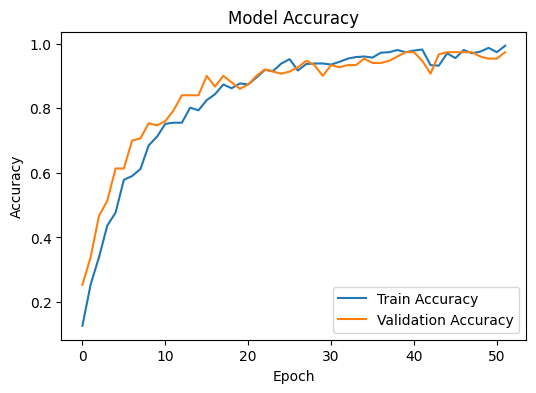

Final Training Accuracy: 0.9933333396911621
Final Validation Accuracy: 0.9733333587646484


In [ ]:
# STEP 10 — Show accuracy graph

import matplotlib.pyplot as plt

train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(6,4))
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("Final Training Accuracy:", train_acc[-1])
print("Final Validation Accuracy:", val_acc[-1])

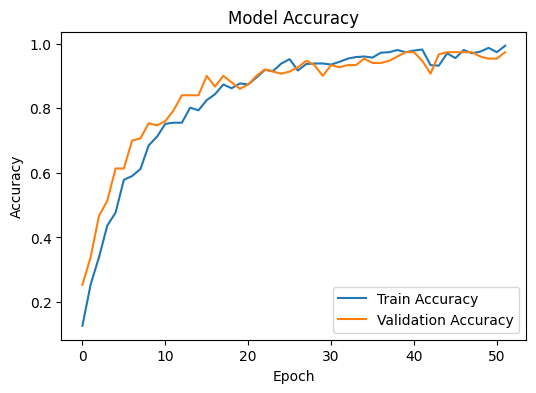

In [ ]:

# -------------------------
# Plot accuracy graph
# -------------------------
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

In [ ]:
import os

save_path = "/content/drive/MyDrive/SignNumberModel/model"
os.makedirs(save_path, exist_ok=True)

model.save("/content/drive/MyDrive/SignNumberModel/model/number_sign_level4.keras")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
from google.colab import output
import base64

def save_video(data):

    video_bytes = base64.b64decode(data.split(",")[1])

    with open("/content/live_capture.webm","wb") as f:
        f.write(video_bytes)

    print("Saved video → /content/live_capture.webm")

output.register_callback("notebook.save_video", save_video)

In [ ]:
from google.colab import files
import cv2
import numpy as np
import mediapipe as mp

uploaded = files.upload()

video_path = list(uploaded.keys())[0]

print("Uploaded:", video_path)

Saving WIN_20260305_15_35_53_Pro.mp4 to WIN_20260305_15_35_53_Pro.mp4
Uploaded: WIN_20260305_15_35_53_Pro.mp4


In [ ]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(static_image_mode=False, max_num_hands=1)

cap = cv2.VideoCapture(video_path)

sequence = []

while cap.isOpened():

    ret, frame = cap.read()
    if not ret:
        break

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(img)

    if results.multi_hand_landmarks:

        for hand_landmarks in results.multi_hand_landmarks:

            keypoints = []

            for lm in hand_landmarks.landmark:
                keypoints.extend([lm.x, lm.y, lm.z])

            sequence.append(keypoints)

cap.release()

sequence = np.array(sequence)

print("Landmark frames:", sequence.shape)

Landmark frames: (19, 63)


In [ ]:
SEQ_LEN = 40

if len(sequence) >= SEQ_LEN:
    idx = np.linspace(0, len(sequence)-1, SEQ_LEN).astype(int)
    sequence_fixed = sequence[idx]
else:
    padding = np.zeros((SEQ_LEN-len(sequence),63))
    sequence_fixed = np.vstack((sequence,padding))

In [ ]:
mean = np.mean(sequence_fixed, axis=0)
std = np.std(sequence_fixed, axis=0) + 1e-6

sequence_fixed = (sequence_fixed - mean) / std

X_live = np.expand_dims(sequence_fixed, axis=0)

probs = model.predict(X_live)[0]

pred_index = np.argmax(probs)

class_names = ['72','74','75','76','78','80','83','84','85','88','90','92','94','95','96','97','98','99','100']

print("Predicted:", class_names[pred_index])
print("Confidence:", probs[pred_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
Predicted: 95
Confidence: 0.9242409


In [ ]:
# STEP 12A — Register save function

from google.colab import output
import base64

def save_video(data):

    # decode base64 video
    video_bytes = base64.b64decode(data.split(",")[1])

    # save video
    with open("/content/live_capture.webm", "wb") as f:
        f.write(video_bytes)

    print("Saved video → /content/live_capture.webm")

# register callback
output.register_callback("notebook.save_video", save_video)

In [ ]:
from IPython.display import Javascript, display

display(Javascript("""
(async () => {

const video = document.createElement("video");
video.autoplay = true;
video.width = 320;

const btn = document.createElement("button");
btn.innerText = "🎥 Record 4s";

const status = document.createElement("div");

document.body.appendChild(video);
document.body.appendChild(btn);
document.body.appendChild(status);

let stream = await navigator.mediaDevices.getUserMedia({video:true});
video.srcObject = stream;

status.innerText = "Preview ready. Click Record.";

btn.onclick = async () => {

status.innerText = "Recording 4 seconds...";

const recorder = new MediaRecorder(stream);
let chunks = [];

recorder.ondataavailable = e => chunks.push(e.data);

recorder.start();

await new Promise(r => setTimeout(r,4000));

recorder.stop();

await new Promise(r => recorder.onstop = r);

let blob = new Blob(chunks,{type:"video/webm"});

let reader = new FileReader();
reader.readAsDataURL(blob);

reader.onloadend = () => {

google.colab.kernel.invokeFunction(
"notebook.save_video",
[reader.result],
{}
);

};

status.innerText = "Recording finished and sent to Python.";

};

})();
"""))

<IPython.core.display.Javascript object>

Saved video → /content/live_capture.webm


In [ ]:
import os

print("File exists:", os.path.exists("/content/live_capture.webm"))

print("File size:", os.path.getsize("/content/live_capture.webm"))

File exists: True
File size: 776187


In [ ]:
import cv2
import mediapipe as mp
import numpy as np

video_path = "/content/live_capture.webm"

mp_hands = mp.solutions.hands

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6
)

cap = cv2.VideoCapture(video_path)

sequence = []
frame_count = 0

while cap.isOpened():

    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1

    img = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    results = hands.process(img)

    if results.multi_hand_landmarks:

        for hand_landmarks in results.multi_hand_landmarks:

            keypoints = []

            for lm in hand_landmarks.landmark:
                keypoints.extend([lm.x, lm.y, lm.z])

            sequence.append(keypoints)

cap.release()

sequence = np.array(sequence)

print("Frames detected:", frame_count)
print("Landmark frames:", sequence.shape)

Frames detected: 60
Landmark frames: (60, 63)


In [ ]:
SEQ_LEN = 40

if len(sequence) >= SEQ_LEN:

    idx = np.linspace(0, len(sequence)-1, SEQ_LEN).astype(int)
    sequence_fixed = sequence[idx]

else:

    padding = np.zeros((SEQ_LEN-len(sequence),63))
    sequence_fixed = np.vstack((sequence,padding))

print("Fixed sequence shape:", sequence_fixed.shape)

Fixed sequence shape: (40, 63)


In [ ]:
mean = np.mean(sequence_fixed, axis=0)
std = np.std(sequence_fixed, axis=0) + 1e-6

sequence_fixed = (sequence_fixed - mean) / std

X_live = np.expand_dims(sequence_fixed, axis=0)

print("Model input shape:", X_live.shape)

Model input shape: (1, 40, 63)


In [ ]:
probs = model.predict(X_live)[0]

pred_index = np.argmax(probs)

print("Predicted index:", pred_index)
print("Confidence:", probs[pred_index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Predicted index: 0
Confidence: 0.98331475


In [ ]:
class_names = ['72','74','75','76','78','80','83','84','85','88','90','92','94','95','96','97','98','99','100']

print("Predicted number:", class_names[pred_index])

Predicted number: 72


In [ ]:
from google.colab import files

files.download("/content/drive/MyDrive/SignNumberModel/model/number_sign_level4.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>